<a href="https://colab.research.google.com/github/AshrfCode/Data-Mining-and-Machine-Learning/blob/main/lab9_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running the example, the accuracy on the training and validation test is printed
each epoch and at the end of the classification error rate is printed.

Note: Your results may vary given the stochastic nature of the algorithm or
evaluation procedure, or differences in numerical precision. Consider running the example
a few times and compare the average outcome.

In [ ]:
import numpy as np
import random
# Simple ANN for the FaSion_MNIST Dataset
from keras.datasets import fashion_mnist,mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
# plot data samples
def plotSamples(data,rows,cols,tLabels,names,pLabels=[]):
    fig, axs = plt.subplots(rows,cols)
    nDigits = data.shape[0]
    for i in range(rows):
        for j in range(cols):
            index = random.randint(0,nDigits-1)
            axs[i,j].imshow(data[index],cmap = 'gray')
            # remove axes titles
            axs[i,j].axis('off')
            if (np.any(pLabels)):
                axs[i,j].set_title('P: %s, T: %s' % (
                    names[pLabels[index]], names[tLabels[index]]) ,fontdict={'fontsize': 10})
            else:
                axs[i,j].set_title('T: %s' % names[tLabels[index]],fontdict={'fontsize': 10})
            # show the figure
    plt.show()

In [ ]:
# define a simple ANN model
def baseline_model(nClasses):
	# create model
    model = Sequential()
    model.add(Flatten(input_shape=[28, 28]))
    model.add(Dense(50, activation="relu"))
    model.add(Dense(nClasses, activation="softmax"))
	# Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam',
                  metrics=['accuracy'])
    return model

In [ ]:
def plotTrainingCurves(history,numEpochs):
  #Process ploting
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_accuracy'])
  plt.plot(history.history['val_loss'])
  plt.axis([0,numEpochs,0,1])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Accuracy','loss','val_accuracy','val_loss'], loc='lower left')
  plt.show()

In [ ]:
# load data
(trainData, trainLabels), (testData, testLabels) = fashion_mnist.load_data()
# summarize loaded dataset
print('Train: X=%s, y=%s' % (trainData.shape, trainLabels.shape))
print('Test: X=%s, y=%s' % (testData.shape, testLabels.shape))

Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


In [ ]:
names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

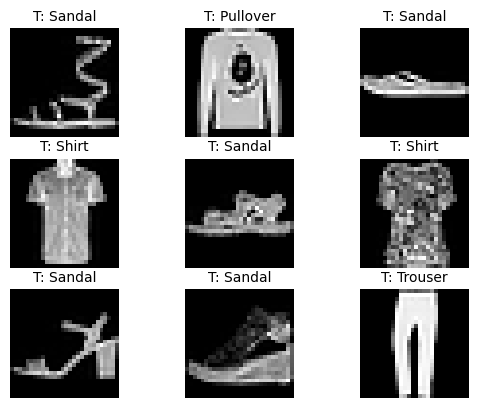

In [ ]:
# plot random 9 images
rows = 3
cols = 3

plotSamples(trainData,rows,cols,trainLabels,names)

In [ ]:
# encode outputs
catTrainLabels = to_categorical(trainLabels)
catTestLabels = to_categorical(testLabels)

In [ ]:
XtrainData = trainData/255.0
XtestData = testData/255.0

In [ ]:
# build the model
nClasses = catTestLabels.shape[1]
model = baseline_model(nClasses)
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,760 (155.31 KB)

 Trainable params: 39,760 (155.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
numEpochs = 10
history=model.fit(XtrainData, catTrainLabels, validation_data=(XtestData, catTestLabels),
                  epochs=numEpochs, batch_size=200)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7857 - loss: 0.6548 - val_accuracy: 0.8237 - val_loss: 0.5110
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8441 - loss: 0.4501 - val_accuracy: 0.8415 - val_loss: 0.4573
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8561 - loss: 0.4117 - val_accuracy: 0.8373 - val_loss: 0.4549
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8613 - loss: 0.3928 - val_accuracy: 0.8492 - val_loss: 0.4221
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8691 - loss: 0.3724 - val_accuracy: 0.8530 - val_loss: 0.4144
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8725 - loss: 0.3618 - val_accuracy: 0.8443 - val_loss: 0.4313
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8762 - loss: 0.3494 - val_accuracy: 0.8594 - val_loss: 0.3893
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8797 - loss: 0.3391 - val_accuracy: 0.

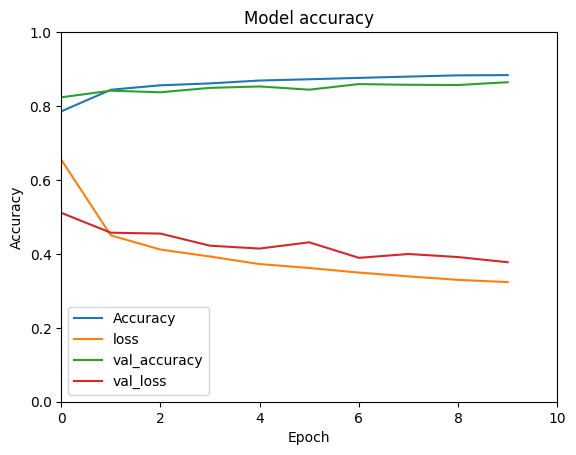

In [ ]:
plotTrainingCurves(history,numEpochs)

In [ ]:
# Final evaluation of the model
scores = model.evaluate(XtestData, catTestLabels, verbose=0)
print("ANN validation accuracy: %.2f" % (scores[1]))

ANN validation accuracy: 0.86


In [ ]:
#make  predictions
predLabels = model.predict(testData).argmax(1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


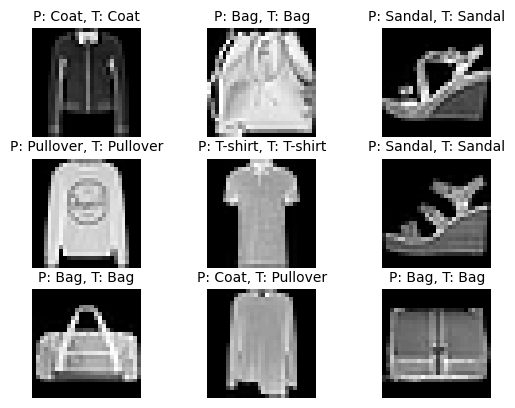

In [ ]:
# plot random 9 images
plotSamples(XtestData,rows,cols,testLabels,names,predLabels)

# Question **1**

In [ ]:
def calculate_model_size(layers):
    total_params = 0
    # Iterate through the layers to calculate weights + biases
    for i in range(len(layers) - 1):
        weights = layers[i] * layers[i+1]
        biases = layers[i+1]
        layer_params = weights + biases
        total_params += layer_params
        print(f"Layer {i+1} to {i+2} parameters: {layer_params}")

    # Each parameter uses 4 bytes
    memory_bytes = total_params * 4
    memory_mb = memory_bytes / (1024 * 1024)

    print(f"\nTotal Parameters: {total_params}")
    print(f"Total Memory Usage: {memory_mb:.6f} MB\n")
    print("Verification according to the model:")
    print(f"Total Memory Usage: {model.count_params()}")

    return total_params, memory_mb

# Test with your specific architecture
layers_list = [784, 50, 10]
calculate_model_size(layers_list)

Layer 1 to 2 parameters: 39250
Layer 2 to 3 parameters: 510

Total Parameters: 39760
Total Memory Usage: 0.151672 MB

Verification according to the model:
Total Memory Usage: 39760


(39760, 0.15167236328125)

# **Question 2**

In [ ]:
def new_model_with_new_dense(nClasses):
  	# create model
    model = Sequential()
    model.add(Flatten(input_shape=[28, 28]))
    model.add(Dense(50, activation="relu"))
    model.add(Dense(32, activation="relu")) # Adding the new layer
    # Compile model
    model.add(Dense(nClasses, activation="softmax"))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model_new_with_new_dense = new_model_with_new_dense(nClasses)
model_new_with_new_dense.summary()


# Fit the model
numEpochs = 10
history2=model_new_with_new_dense.fit(XtrainData, catTrainLabels, validation_data=(XtestData, catTestLabels),
                  epochs=numEpochs, batch_size=200)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,212 (160.98 KB)

 Trainable params: 41,212 (160.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7742 - loss: 0.6847 - val_accuracy: 0.8278 - val_loss: 0.4927
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8452 - loss: 0.4447 - val_accuracy: 0.8411 - val_loss: 0.4521
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8601 - loss: 0.4023 - val_accuracy: 0.8486 - val_loss: 0.4260
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8658 - loss: 0.3789 - val_accuracy: 0.8564 - val_loss: 0.4064
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8735 - loss: 0.3575 - val_accuracy: 0.8622 - val_loss: 0.3920
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8783 - loss: 0.3419 - val_accuracy: 0.8619 - val_loss: 0.3859
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8820 - loss: 0.3305 - val_accuracy: 0.8578 - val_loss: 0.3947
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8849 - loss: 0.3228 - val_accuracy: 0.

# **Question 3**

In [ ]:
scores_new = model_new_with_new_dense.evaluate(XtestData, catTestLabels, verbose=0)

print("Original model:")
print("Parameters:", model.count_params())
print("Memory MB:", model.count_params() * 4 / (1024 ** 2))
# print("Runtime:", runtime1)
print("Validation accuracy:", scores[1])

print("\nNew model:")
print("Parameters:", model_new_with_new_dense.count_params())
print("Memory MB:", model_new_with_new_dense.count_params() * 4 / (1024 ** 2))
# print("Runtime:", runtime2)
print("Validation accuracy:", scores_new[1])

Original model:
Parameters: 39760
Memory MB: 0.15167236328125
Validation accuracy: 0.8644999861717224

New model:
Parameters: 41212
Memory MB: 0.1572113037109375
Validation accuracy: 0.8658999800682068


# Question **4**

In [ ]:
def plot_two_training_curves(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title(title + " Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(["accuracy", "val_accuracy"])
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title(title + " Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["loss", "val_loss"])
    plt.grid(True)
    plt.show()

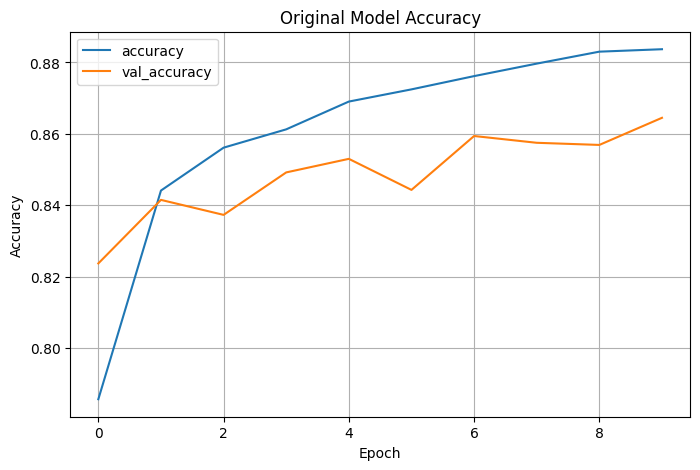

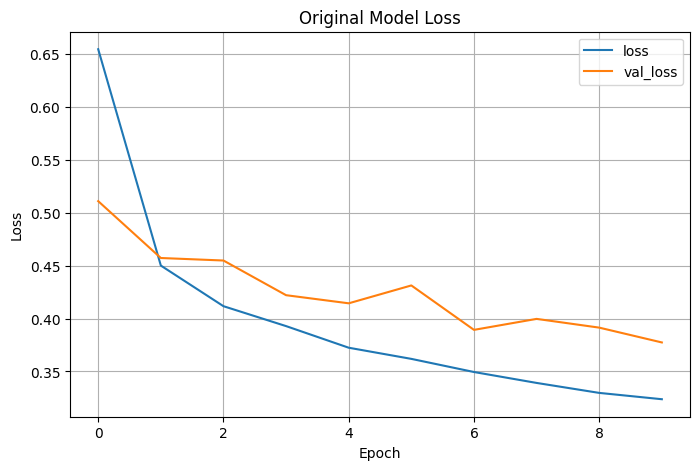

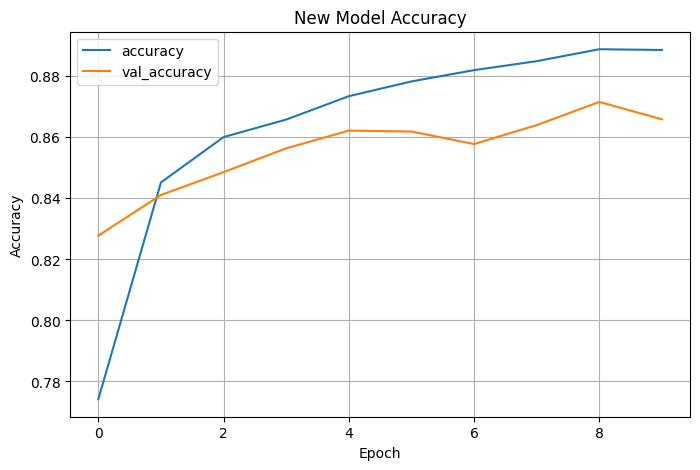

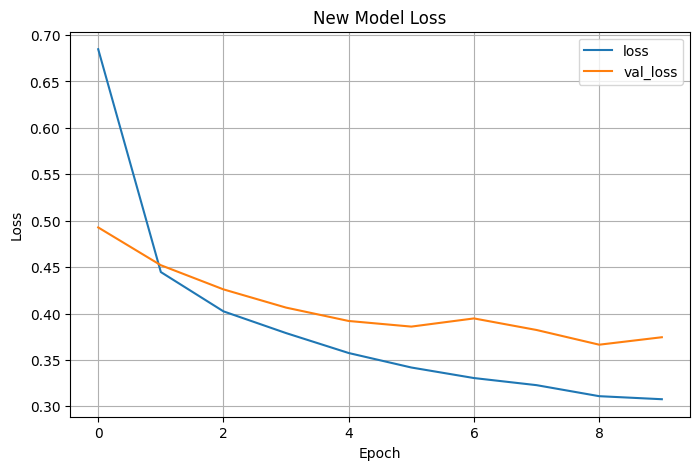

In [ ]:
plot_two_training_curves(history, "Original Model")
plot_two_training_curves(history2, "New Model")

# **Question 5**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


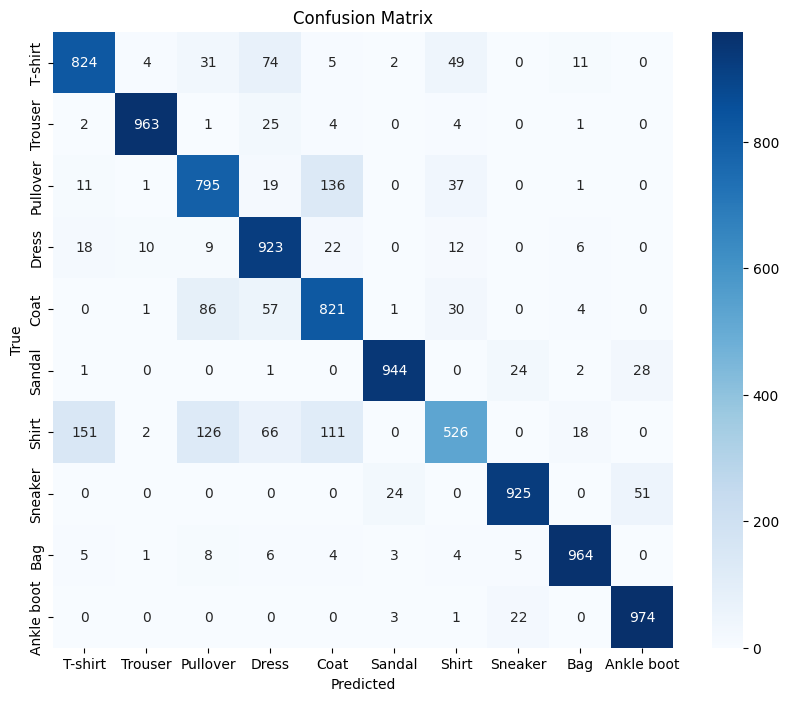

Most confused pair: True 'Shirt' misclassified as 'T-shirt'


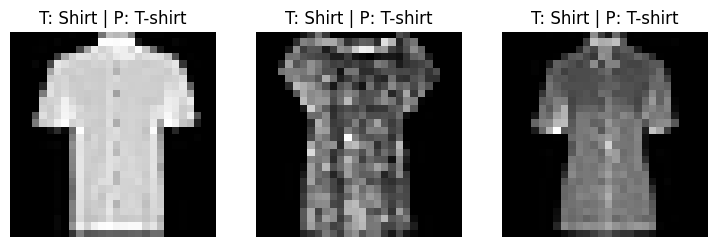

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# 1. Run prediction
predLabels_new = model_new_with_new_dense.predict(XtestData).argmax(axis=1)

# 2. Plot confusion matrix
cm = confusion_matrix(testLabels, predLabels_new)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 3. Find most confused pair
np.fill_diagonal(cm, 0) # Ignore correct predictions
max_confused_idx = np.unravel_index(np.argmax(cm, axis=None), cm.shape)
true_class = max_confused_idx[0]
pred_class = max_confused_idx[1]
print(f"Most confused pair: True '{names[true_class]}' misclassified as '{names[pred_class]}'")

# 4. Plot 3 images of this specific confusion
confused_indices = np.where((testLabels == true_class) & (predLabels_new == pred_class))[0]

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
for i in range(min(3, len(confused_indices))):
    idx = confused_indices[i]
    axs[i].imshow(XtestData[idx], cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f"T: {names[true_class]} | P: {names[pred_class]}")
plt.show()

# **Question 6**

In [ ]:
# load data specifically for the digits
(mnist_trainX, mnist_trainy), (mnist_testX, mnist_testy) = mnist.load_data()

# summarize loaded dataset
print('MNIST Train: X=%s, y=%s' % (mnist_trainX.shape, mnist_trainy.shape))
print('MNIST Test: X=%s, y=%s' % (mnist_testX.shape, mnist_testy.shape))

MNIST Train: X=(60000, 28, 28), y=(60000,)
MNIST Test: X=(10000, 28, 28), y=(10000,)


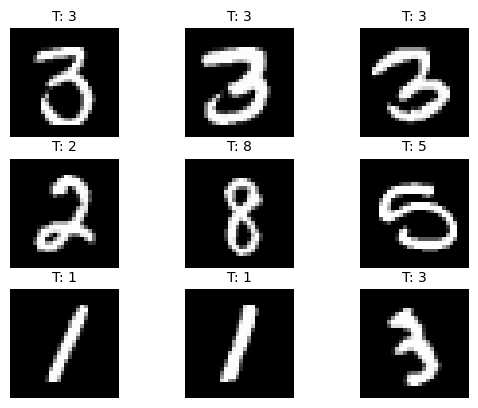

In [ ]:
# plot random 9 images of the numbers
mnist_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
plotSamples(mnist_trainX, rows, cols, mnist_trainy, mnist_names)

# **Question 7**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8604 - loss: 0.5137 - val_accuracy: 0.9254 - val_loss: 0.2684
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9322 - loss: 0.2430 - val_accuracy: 0.9390 - val_loss: 0.2091
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9462 - loss: 0.1913 - val_accuracy: 0.9494 - val_loss: 0.1751
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9553 - loss: 0.1589 - val_accuracy: 0.9565 - val_loss: 0.1508
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9610 - loss: 0.1358 - val_accuracy: 0.9603 - val_loss: 0.1391
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9663 - loss: 0.1186 - val_accuracy: 0.9626 - val_loss: 0.1238
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9693 - loss: 0.1069 - val_accuracy: 0.9660 - val_loss: 0.1189
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9721 - loss: 0.0971 - val_accuracy: 0.

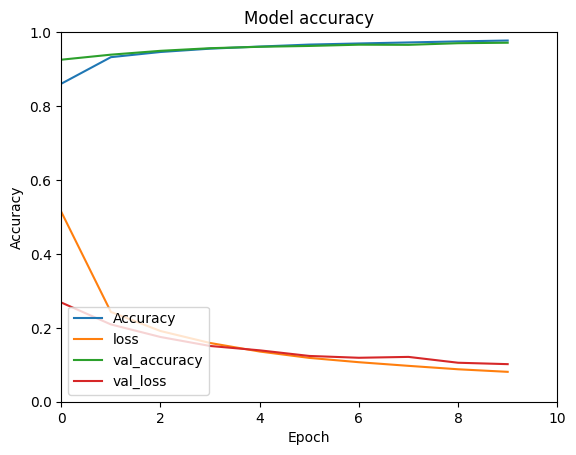

MNIST Validation accuracy: 0.97


In [ ]:
from keras.utils import to_categorical

# 1. Preprocess the MNIST data
Xtrain_mnist = mnist_trainX / 255.0
Xtest_mnist = mnist_testX / 255.0

catTrain_mnist = to_categorical(mnist_trainy)
catTest_mnist = to_categorical(mnist_testy)

# 2. Build and train the baseline model on MNIST
mnist_model = baseline_model(10)
mnist_history = mnist_model.fit(Xtrain_mnist, catTrain_mnist,
                                validation_data=(Xtest_mnist, catTest_mnist),
                                epochs=10, batch_size=200)

# 3. Plot the training curves and print final accuracy
plotTrainingCurves(mnist_history, 10)

scores_mnist = mnist_model.evaluate(Xtest_mnist, catTest_mnist, verbose=0)
print("MNIST Validation accuracy: %.2f" % (scores_mnist[1]))

# **Question 8**

In [ ]:
from keras.callbacks import EarlyStopping

def minimal_model(nClasses):
    model = Sequential()
    model.add(Flatten(input_shape=[28, 28]))
    model.add(Dense(16, activation="relu")) # Reduced from 50 to 16
    model.add(Dense(nClasses, activation="softmax"))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Early stopping will stop training when val_loss stops improving for 2 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train Minimal Model on Fashion MNIST
min_fmnist = minimal_model(10)
print("Minimal Model Parameters:")
min_fmnist.summary()

history_min_fmnist = min_fmnist.fit(XtrainData, catTrainLabels,
                                    validation_data=(XtestData, catTestLabels),
                                    epochs=50, # Set high, early stopping will cut it short
                                    batch_size=200,
                                    callbacks=[early_stop])

print(f"Stopped at epoch: {len(history_min_fmnist.history['loss'])}")

Minimal Model Parameters:


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,730 (49.73 KB)

 Trainable params: 12,730 (49.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7229 - loss: 0.8633 - val_accuracy: 0.7841 - val_loss: 0.6234
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8238 - loss: 0.5170 - val_accuracy: 0.8262 - val_loss: 0.5114
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8393 - loss: 0.4636 - val_accuracy: 0.8349 - val_loss: 0.4788
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8467 - loss: 0.4372 - val_accuracy: 0.8406 - val_loss: 0.4590
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8544 - loss: 0.4150 - val_accuracy: 0.8443 - val_loss: 0.4457
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8589 - loss: 0.4022 - val_accuracy: 0.8496 - val_loss: 0.4305
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8616 - loss: 0.3921 - val_accuracy: 0.8477 - val_loss: 0.4314
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8656 - loss: 0.3812 - val_accuracy: 0.

In [ ]:
from keras.datasets import fashion_mnist, mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# 1. DEFINE THE OPTIMAL MINIMAL MODEL
# ---------------------------------------------------------
def minimal_model(nClasses):
    model = Sequential()
    model.add(Flatten(input_shape=[28, 28]))
    model.add(Dense(16, activation="relu")) # Reduced parameters from 50 to 16
    model.add(Dense(nClasses, activation="softmax"))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ---------------------------------------------------------
# 2. LOAD AND PREPROCESS BOTH DATASETS
# ---------------------------------------------------------
# Fashion-MNIST
(fashion_trainX, fashion_trainy), (fashion_testX, fashion_testy) = fashion_mnist.load_data()
Xtrain_fashion = fashion_trainX / 255.0
Xtest_fashion = fashion_testX / 255.0
catTrain_fashion = to_categorical(fashion_trainy)
catTest_fashion = to_categorical(fashion_testy)

# MNIST (Digits)
(mnist_trainX, mnist_trainy), (mnist_testX, mnist_testy) = mnist.load_data()
Xtrain_mnist = mnist_trainX / 255.0
Xtest_mnist = mnist_testX / 255.0
catTrain_mnist = to_categorical(mnist_trainy)
catTest_mnist = to_categorical(mnist_testy)

# ---------------------------------------------------------
# 3. SETUP EARLY STOPPING ("stop when not good anymore")
# ---------------------------------------------------------
# Stops training if val_loss doesn't improve for 2 epochs, and keeps the best weights
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ---------------------------------------------------------
# 4. TRAIN AND EVALUATE ON FASHION-MNIST
# ---------------------------------------------------------
print("--- Training Minimal Model on Fashion-MNIST ---")
min_fashion_model = minimal_model(10)

# We set epochs high (e.g., 50), but early_stop will cut it short automatically
fashion_history = min_fashion_model.fit(Xtrain_fashion, catTrain_fashion,
                                        validation_data=(Xtest_fashion, catTest_fashion),
                                        epochs=50, batch_size=200, verbose=0,
                                        callbacks=[early_stop])

fashion_epochs = len(fashion_history.history['loss'])
fashion_scores = min_fashion_model.evaluate(Xtest_fashion, catTest_fashion, verbose=0)
print(f"Fashion-MNIST stopped early at epoch: {fashion_epochs}")

# ---------------------------------------------------------
# 5. TRAIN AND EVALUATE ON MNIST (DIGITS)
# ---------------------------------------------------------
print("\n--- Training Minimal Model on MNIST (Digits) ---")
min_mnist_model = minimal_model(10)

mnist_history = min_mnist_model.fit(Xtrain_mnist, catTrain_mnist,
                                    validation_data=(Xtest_mnist, catTest_mnist),
                                    epochs=50, batch_size=200, verbose=0,
                                    callbacks=[early_stop])

mnist_epochs = len(mnist_history.history['loss'])
mnist_scores = min_mnist_model.evaluate(Xtest_mnist, catTest_mnist, verbose=0)
print(f"MNIST Digits stopped early at epoch: {mnist_epochs}")

# ---------------------------------------------------------
# 6. FINAL COMPARISON
# ---------------------------------------------------------
print("\n--- Final Optimal Model Comparison ---")
print(f"Fashion-MNIST:  Stopped at Epoch {fashion_epochs:02d} | Validation Accuracy: {fashion_scores[1]:.4f}")
print(f"MNIST (Digits): Stopped at Epoch {mnist_epochs:02d} | Validation Accuracy: {mnist_scores[1]:.4f}")

--- Training Minimal Model on Fashion-MNIST ---
Fashion-MNIST stopped early at epoch: 13

--- Training Minimal Model on MNIST (Digits) ---
MNIST Digits stopped early at epoch: 18

--- Final Optimal Model Comparison ---
Fashion-MNIST:  Stopped at Epoch 13 | Validation Accuracy: 0.8593
MNIST (Digits): Stopped at Epoch 18 | Validation Accuracy: 0.9489
